# Home Credit Default Risk — Phase 2b/2c: Advanced Feature Selection + Business Insights

**Run this AFTER Phase 2 and BEFORE Phase 3.**

This notebook fills the three gaps identified after Phase 2:

| Gap | What we add | Why it matters |
|---|---|---|
| Feature selection depth | Mutual Information, Information Value (IV), LightGBM importance | Pearson misses non-linear relationships; IV is the credit-industry standard |
| Segmentation analysis | Default rate by income group, employment type, region, age band | Required for MNC risk presentations and regulatory decks |
| Business-level insights | WHY + WHAT ACTION per finding | Observations without recommendations are incomplete analysis |

In [2]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from IPython.display import display, HTML
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import LabelEncoder

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 60)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')

plt.rcParams.update({
    'figure.facecolor':'#FAFAFA','axes.facecolor':'#FAFAFA',
    'axes.spines.top':False,'axes.spines.right':False,
    'axes.labelsize':11,'xtick.labelsize':9,'ytick.labelsize':9,
})
C0, C1, C2 = '#534AB7', '#D85A30', '#1D9E75'
PALETTE = [C0, C1]

DATA_DIR   = '../data'       # raw CSVs
OUTPUT_DIR = './phase2b_outputs/'
os.makedirs(OUTPUT_DIR, exist_ok=True)

train = pd.read_csv(os.path.join(DATA_DIR, 'application_train.csv'))
print(f'Loaded application_train: {train.shape}')
print(f'Default rate: {train["TARGET"].mean()*100:.2f}%')

ID_COLS    = ['SK_ID_CURR']
TARGET_COL = 'TARGET'
OVERALL_DR = train[TARGET_COL].mean()

Loaded application_train: (307511, 122)
Default rate: 8.07%


In [3]:
# ── Prepare working copy ──────────────────────────────────────────────────────
df = train.copy()

# Fix DAYS_EMPLOYED anomaly
if 'DAYS_EMPLOYED' in df.columns:
    df['DAYS_EMPLOYED_ANOM'] = (df['DAYS_EMPLOYED'] == 365243).astype(int)
    df['DAYS_EMPLOYED'] = df['DAYS_EMPLOYED'].replace(365243, np.nan)

# Label encode categoricals (fit on train only — this is for scoring only, not Phase 3)
cat_cols = [c for c in df.select_dtypes('object').columns if c not in ID_COLS]
le_map   = {}
for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].fillna('Missing').astype(str))
    le_map[col] = le

# ── Smart imputation — strategy depends on column type ────────────────────────
# Rule: never use inplace=True (silent fail in pandas 2.x — always direct assign)
num_cols = [c for c in df.select_dtypes(include='number').columns
            if c not in ID_COLS + [TARGET_COL]]

ZERO_FILL_COLS = [
    # Count columns — null means no event occurred, 0 is factually correct
    'AMT_REQ_CREDIT_BUREAU_HOUR', 'AMT_REQ_CREDIT_BUREAU_DAY',
    'AMT_REQ_CREDIT_BUREAU_WEEK', 'AMT_REQ_CREDIT_BUREAU_MON',
    'AMT_REQ_CREDIT_BUREAU_QRT',  'AMT_REQ_CREDIT_BUREAU_YEAR',
    'OBS_30_CNT_SOCIAL_CIRCLE',   'DEF_30_CNT_SOCIAL_CIRCLE',
    'OBS_60_CNT_SOCIAL_CIRCLE',   'DEF_60_CNT_SOCIAL_CIRCLE',
]
MODE_FILL_COLS = ['CNT_CHILDREN', 'CNT_FAM_MEMBERS']

for col in num_cols:
    if df[col].isnull().sum() == 0:
        continue
    if col in ZERO_FILL_COLS:
        df[col] = df[col].fillna(0)
    elif col in MODE_FILL_COLS:
        df[col] = df[col].fillna(df[col].mode()[0])
    else:
        # Median for skewed financial cols, DAYS cols, EXT_SOURCE, normalized scores
        df[col] = df[col].fillna(df[col].median())

ALL_FEATURE_COLS = [c for c in df.columns if c not in ID_COLS + [TARGET_COL]]
X = df[ALL_FEATURE_COLS]
y = df[TARGET_COL]

print(f'Feature matrix ready: {X.shape}')
print(f'Remaining nulls: {X.isnull().sum().sum()}')  # must be 0
print(f'\nImputation strategy applied:')
print(f'  Zero-fill (count cols) : {len([c for c in ZERO_FILL_COLS if c in num_cols])}')
print(f'  Mode-fill (count cols) : {len([c for c in MODE_FILL_COLS if c in num_cols])}')
print(f'  Median-fill (rest)     : remaining numeric cols')


Feature matrix ready: (307511, 121)
Remaining nulls: 0

Imputation strategy applied:
  Zero-fill (count cols) : 10
  Mode-fill (count cols) : 2
  Median-fill (rest)     : remaining numeric cols


Computing Mutual Information scores... (takes ~60 seconds)

Top 25 features by Mutual Information:


,Feature,MI_Score
0,FLAG_MOBIL,0.0398
1,FLAG_CONT_MOBILE,0.0290
2,FLAG_DOCUMENT_3,0.0286
3,FLAG_EMP_PHONE,0.0281
4,FLAG_OWN_REALTY,0.0274
5,NAME_HOUSING_TYPE,0.0264
6,FLOORSMIN_AVG,0.0238
7,FLOORSMIN_MODE,0.0234
8,FLOORSMIN_MEDI,0.0228
9,NAME_TYPE_SUITE,0.0197


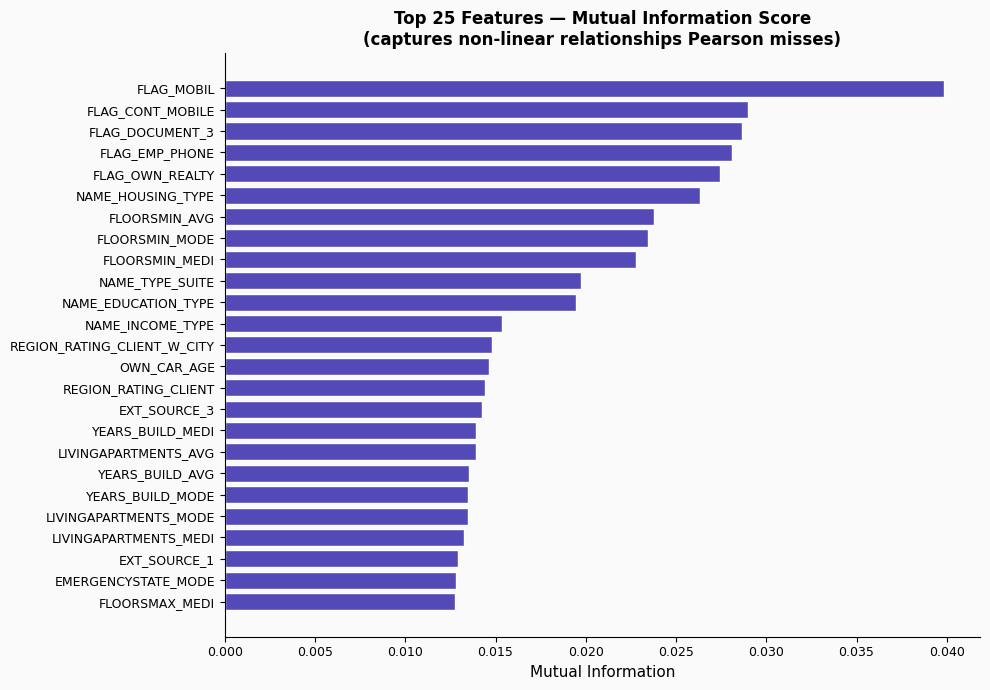


Features in MI top-20 but NOT in Pearson top-20 (non-linear signals):
  FLAG_CONT_MOBILE
  FLAG_MOBIL
  FLAG_OWN_REALTY
  FLOORSMIN_AVG
  FLOORSMIN_MEDI
  FLOORSMIN_MODE
  LIVINGAPARTMENTS_AVG
  NAME_HOUSING_TYPE
  NAME_TYPE_SUITE
  OWN_CAR_AGE
  YEARS_BUILD_AVG
  YEARS_BUILD_MEDI
  YEARS_BUILD_MODE

→ These are the features Pearson correlation would have underranked or missed.


In [4]:
print('Computing Mutual Information scores... (takes ~60 seconds)')
mi_scores = mutual_info_classif(
    X, y,
    discrete_features='auto',
    n_neighbors=5,
    random_state=42
)
mi_df = pd.DataFrame({
    'Feature' : ALL_FEATURE_COLS,
    'MI_Score': mi_scores
}).sort_values('MI_Score', ascending=False)

print(f'\nTop 25 features by Mutual Information:')
display(mi_df.head(25).reset_index(drop=True))

# Plot
top_mi = mi_df.head(25)
fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(top_mi['Feature'], top_mi['MI_Score'], color=C0, edgecolor='white')
ax.set_title('Top 25 Features — Mutual Information Score\n(captures non-linear relationships Pearson misses)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Mutual Information')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'phase2b_mutual_information.png'), dpi=150, bbox_inches='tight')
plt.show()

# Compare: features Pearson found vs MI found
pearson_top = df[ALL_FEATURE_COLS + [TARGET_COL]].corr()[TARGET_COL].drop(TARGET_COL).abs().sort_values(ascending=False)
pearson_top20 = set(pearson_top.head(20).index)
mi_top20      = set(mi_df.head(20)['Feature'])
only_in_mi    = mi_top20 - pearson_top20
print(f'\nFeatures in MI top-20 but NOT in Pearson top-20 (non-linear signals):')
for f in sorted(only_in_mi):
    print(f'  {f}')
print('\n→ These are the features Pearson correlation would have underranked or missed.')

### Information Value (IV) — Credit Industry Standard

IV is computed using Weight of Evidence (WoE) binning:
- Bin each feature into deciles
- For each bin: WoE = ln(% non-events / % events)
- IV = Σ (% non-events − % events) × WoE

| IV Range | Predictive Power |
|---|---|
| < 0.02 | Useless — drop |
| 0.02 – 0.10 | Weak |
| 0.10 – 0.30 | Medium |
| 0.30 – 0.50 | Strong |
| > 0.50 | Suspicious (possible leakage) |

In [5]:
def compute_iv(series, target, bins=10):
    """
    Compute Information Value for a single feature.
    Uses quantile binning for continuous variables.
    Returns IV value.
    """
    try:
        # Bin the feature
        if series.nunique() > bins:
            binned = pd.qcut(series, q=bins, duplicates='drop')
        else:
            binned = series.astype('category')

        df_bin = pd.DataFrame({'bin': binned, 'target': target})
        stats  = df_bin.groupby('bin', observed=True)['target'].agg(
            events='sum',
            total='count'
        )
        stats['non_events'] = stats['total'] - stats['events']

        total_events     = stats['events'].sum()
        total_non_events = stats['non_events'].sum()

        if total_events == 0 or total_non_events == 0:
            return 0.0

        stats['pct_events']     = stats['events']     / total_events
        stats['pct_non_events'] = stats['non_events'] / total_non_events

        # Avoid log(0)
        stats = stats[(stats['pct_events'] > 0) & (stats['pct_non_events'] > 0)]
        stats['WoE'] = np.log(stats['pct_non_events'] / stats['pct_events'])
        stats['IV']  = (stats['pct_non_events'] - stats['pct_events']) * stats['WoE']

        return round(stats['IV'].sum(), 5)
    except Exception:
        return 0.0


def iv_label(iv):
    if iv < 0.02:  return 'Useless'
    if iv < 0.10:  return 'Weak'
    if iv < 0.30:  return 'Medium'
    if iv < 0.50:  return 'Strong'
    return 'Suspicious (check leakage)'


print('Computing Information Value for all features...')
iv_results = []
for col in ALL_FEATURE_COLS:
    iv = compute_iv(df[col], y)
    iv_results.append({'Feature': col, 'IV': iv, 'Category': iv_label(iv)})

iv_df = pd.DataFrame(iv_results).sort_values('IV', ascending=False)

print('\nIV category summary:')
print(iv_df['Category'].value_counts().to_string())

print('\nTop 30 features by IV:')
display(iv_df.head(30).reset_index(drop=True))

# Features to DROP based on IV (useless, regardless of null %)
useless_iv = iv_df[iv_df['Category'] == 'Useless']['Feature'].tolist()
suspicious_iv = iv_df[iv_df['Category'].str.startswith('Suspicious')]['Feature'].tolist()
print(f'\nFeatures with IV < 0.02 (useless, recommend drop): {len(useless_iv)}')
print(f'Features with IV > 0.50 (suspicious, check leakage): {len(suspicious_iv)}')
if suspicious_iv:
    print(f'  {suspicious_iv}')

Computing Information Value for all features...

IV category summary:
Category
Useless    76
Weak       41
Strong      2
Medium      2

Top 30 features by IV:


,Feature,IV,Category
0,EXT_SOURCE_3,0.3138,Strong
1,EXT_SOURCE_2,0.3063,Strong
2,EXT_SOURCE_1,0.1360,Medium
3,DAYS_EMPLOYED,0.1071,Medium
4,AMT_GOODS_PRICE,0.0916,Weak
5,DAYS_BIRTH,0.0842,Weak
6,NAME_INCOME_TYPE,0.0583,Weak
7,REGION_RATING_CLIENT_W_CITY,0.0512,Weak
8,NAME_EDUCATION_TYPE,0.0508,Weak
9,ORGANIZATION_TYPE,0.0504,Weak



Features with IV < 0.02 (useless, recommend drop): 76
Features with IV > 0.50 (suspicious, check leakage): 0


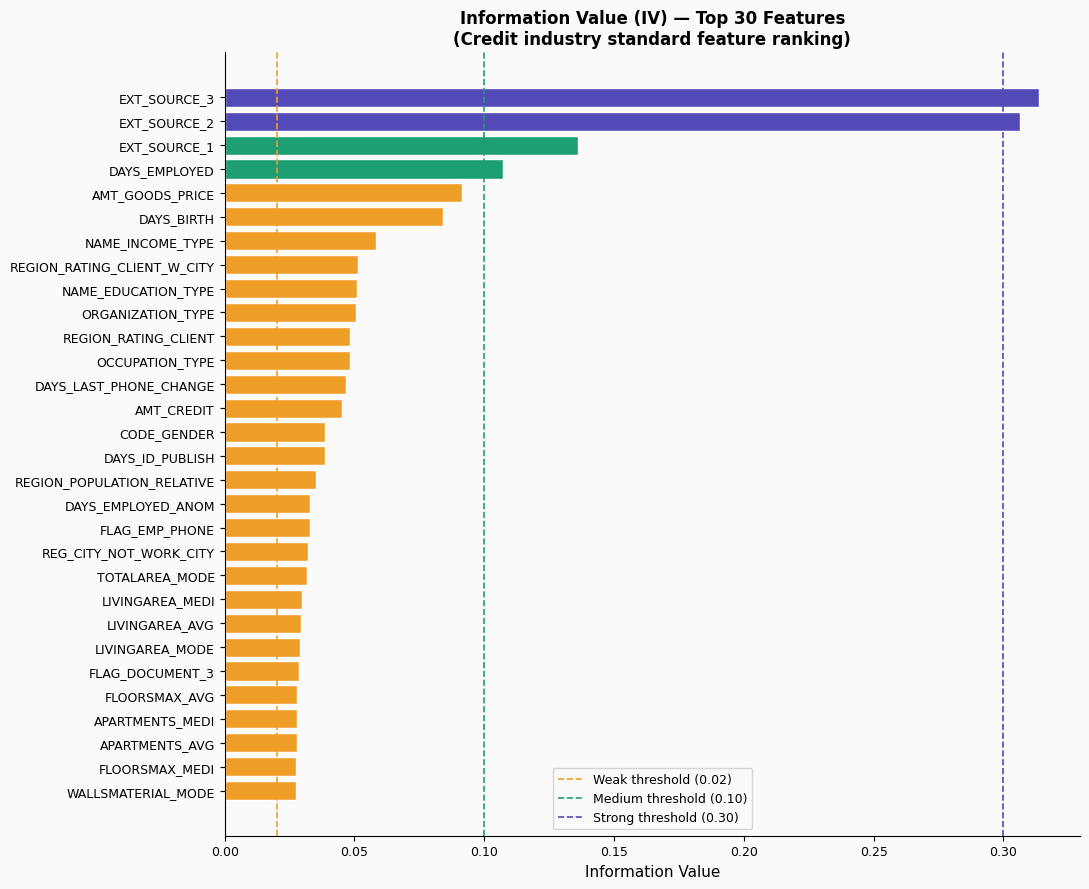

In [6]:
# ── IV bar chart ──────────────────────────────────────────────────────────────
top_iv = iv_df[iv_df['IV'] >= 0.02].head(30)
iv_colors = {
    'Useless': '#CCCCCC',
    'Weak'   : '#EF9F27',
    'Medium' : '#1D9E75',
    'Strong' : '#534AB7',
    'Suspicious (check leakage)': '#D85A30',
}
colors = [iv_colors.get(c, '#999') for c in top_iv['Category']]

fig, ax = plt.subplots(figsize=(11, 9))
ax.barh(top_iv['Feature'], top_iv['IV'], color=colors, edgecolor='white')
ax.axvline(0.02, color='#EF9F27', linestyle='--', lw=1.2, label='Weak threshold (0.02)')
ax.axvline(0.10, color='#1D9E75', linestyle='--', lw=1.2, label='Medium threshold (0.10)')
ax.axvline(0.30, color='#534AB7', linestyle='--', lw=1.2, label='Strong threshold (0.30)')
ax.set_title('Information Value (IV) — Top 30 Features\n(Credit industry standard feature ranking)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Information Value')
ax.legend(fontsize=9)
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'phase2b_information_value.png'), dpi=150, bbox_inches='tight')
plt.show()

Training LightGBM for feature importance (100 trees, 5-fold)...
  Fold 1/5 — best AUC: 0.75225  trees: 100
  Fold 2/5 — best AUC: 0.76136  trees: 100
  Fold 3/5 — best AUC: 0.75239  trees: 100
  Fold 4/5 — best AUC: 0.75883  trees: 100
  Fold 5/5 — best AUC: 0.74939  trees: 100

Top 25 features by LightGBM gain (avg across 5 folds):


,Feature,LGB_Importance
0,EXT_SOURCE_3,"301,752.3302"
1,EXT_SOURCE_2,"280,042.6284"
2,EXT_SOURCE_1,"92,215.0019"
3,DAYS_EMPLOYED,"41,059.6593"
4,AMT_CREDIT,"38,295.9269"
5,DAYS_BIRTH,"35,756.9383"
6,AMT_GOODS_PRICE,"33,580.8673"
7,NAME_EDUCATION_TYPE,"31,013.7397"
8,AMT_ANNUITY,"28,858.3308"
9,CODE_GENDER,"26,571.7732"


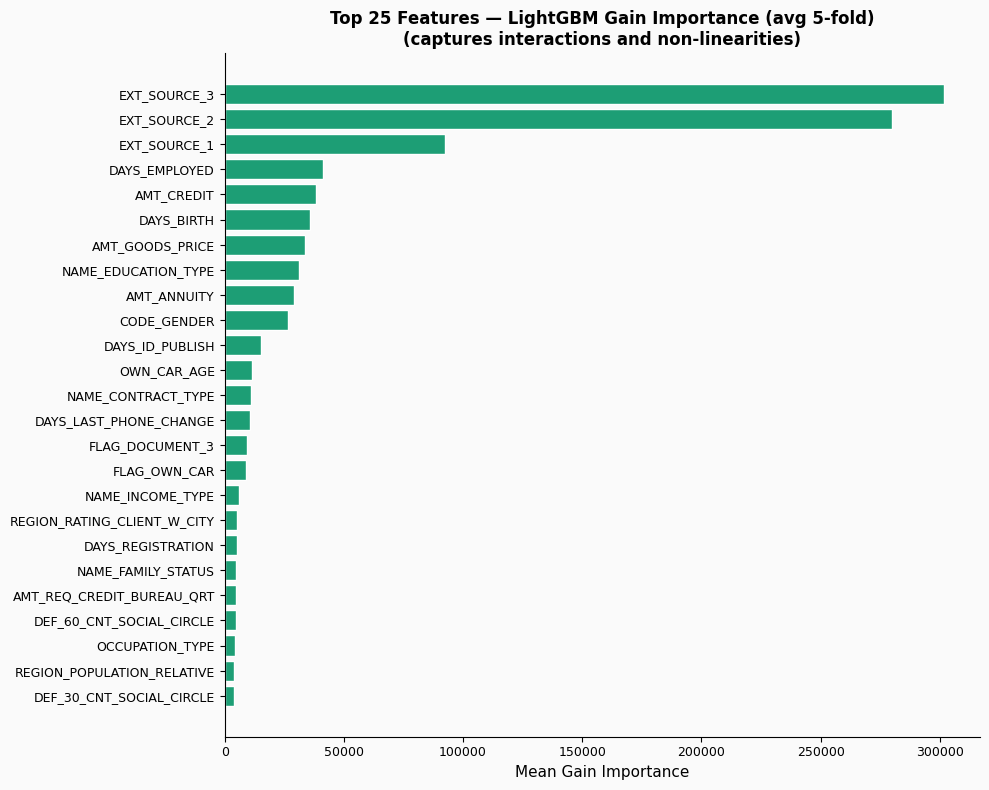

In [7]:
try:
    import lightgbm as lgb
    from sklearn.model_selection import StratifiedKFold

    print('Training LightGBM for feature importance (100 trees, 5-fold)...')

    params = {
        'objective'        : 'binary',
        'metric'           : 'auc',
        'n_estimators'     : 100,
        'learning_rate'    : 0.05,
        'num_leaves'       : 31,
        'min_child_samples': 100,
        'scale_pos_weight' : (y == 0).sum() / (y == 1).sum(),
        'verbose'          : -1,
        'random_state'     : 42,
        'n_jobs'           : -1,
    }

    skf        = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    imp_matrix = np.zeros(len(ALL_FEATURE_COLS))

    for fold, (tr_idx, va_idx) in enumerate(skf.split(X, y)):
        X_tr, X_va = X.iloc[tr_idx], X.iloc[va_idx]
        y_tr, y_va = y.iloc[tr_idx], y.iloc[va_idx]

        dtrain = lgb.Dataset(X_tr, label=y_tr, feature_name=ALL_FEATURE_COLS)
        dval   = lgb.Dataset(X_va, label=y_va, reference=dtrain)

        clf = lgb.train(
            params, dtrain,
            valid_sets=[dval],
            callbacks=[lgb.early_stopping(20, verbose=False), lgb.log_evaluation(period=-1)]
        )
        imp_matrix += clf.feature_importance(importance_type='gain')
        auc = clf.best_score['valid_0']['auc']
        print(f'  Fold {fold+1}/5 — best AUC: {auc:.5f}  trees: {clf.best_iteration}')

    imp_matrix /= 5   # average across folds

    lgb_df = pd.DataFrame({
        'Feature'    : ALL_FEATURE_COLS,
        'LGB_Importance': imp_matrix
    }).sort_values('LGB_Importance', ascending=False)

    print(f'\nTop 25 features by LightGBM gain (avg across 5 folds):')
    display(lgb_df.head(25).reset_index(drop=True))

    # Plot
    top_lgb = lgb_df.head(25)
    fig, ax = plt.subplots(figsize=(10, 8))
    ax.barh(top_lgb['Feature'], top_lgb['LGB_Importance'], color=C2, edgecolor='white')
    ax.set_title('Top 25 Features — LightGBM Gain Importance (avg 5-fold)\n(captures interactions and non-linearities)',
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('Mean Gain Importance')
    ax.invert_yaxis()
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'phase2b_lgb_importance.png'), dpi=150, bbox_inches='tight')
    plt.show()

except ImportError:
    print('LightGBM not installed. Run: pip install lightgbm')
    lgb_df = pd.DataFrame({'Feature': ALL_FEATURE_COLS, 'LGB_Importance': 0})

In [8]:
# ── Pearson scores ────────────────────────────────────────────────────────────
pearson_df = df[ALL_FEATURE_COLS + [TARGET_COL]].corr()[TARGET_COL].drop(TARGET_COL).abs()
pearson_df = pearson_df.reset_index()
pearson_df.columns = ['Feature', 'Pearson_Abs']

# ── Merge all scores ──────────────────────────────────────────────────────────
master_rank = (
    pearson_df
    .merge(mi_df[['Feature','MI_Score']], on='Feature', how='left')
    .merge(iv_df[['Feature','IV','Category']], on='Feature', how='left')
    .merge(lgb_df[['Feature','LGB_Importance']], on='Feature', how='left')
)

# Normalise each score to 0–1, then compute weighted composite
for col in ['Pearson_Abs','MI_Score','IV','LGB_Importance']:
    col_max = master_rank[col].max()
    if col_max > 0:
        master_rank[f'{col}_norm'] = master_rank[col] / col_max
    else:
        master_rank[f'{col}_norm'] = 0

# Weighted composite: LGB 35%, IV 30%, MI 20%, Pearson 15%
# LGB and IV weighted higher — they are more robust
master_rank['Composite_Score'] = (
    0.35 * master_rank['LGB_Importance_norm'] +
    0.30 * master_rank['IV_norm'] +
    0.20 * master_rank['MI_Score_norm'] +
    0.15 * master_rank['Pearson_Abs_norm']
).round(5)

master_rank = master_rank.sort_values('Composite_Score', ascending=False).reset_index(drop=True)
master_rank['Priority_Rank'] = master_rank.index + 1
master_rank['IV_Category']   = master_rank['Category']

# Add null % from original train
# Null % from original train — explicit construction avoids rename ambiguity
null_pct_series = train.isnull().mean()
null_pct_df     = pd.DataFrame({
    'Feature' : null_pct_series.index,
    'Null_Pct': null_pct_series.values
})
master_rank = master_rank.merge(null_pct_df, on='Feature', how='left')

# Final columns to display
display_cols = ['Priority_Rank','Feature','Composite_Score','IV','IV_Category',
                'MI_Score','Pearson_Abs','LGB_Importance','Null_Pct']
display_cols = [c for c in display_cols if c in master_rank.columns]

print('MASTER FEATURE PRIORITY TABLE — Top 40')
display(
    master_rank[display_cols].head(40).style
    .format({
        'Composite_Score': '{:.4f}',
        'IV': '{:.4f}',
        'MI_Score': '{:.4f}',
        'Pearson_Abs': '{:.4f}',
        'LGB_Importance': '{:.0f}',
        'Null_Pct': '{:.1%}'
    })
    .background_gradient(subset=['Composite_Score'], cmap='Greens')
    .background_gradient(subset=['IV'], cmap='Blues')
    .background_gradient(subset=['Null_Pct'], cmap='Oranges')
    .set_caption('Master Feature Priority Table (Phase 3 input)')
)

# Save
master_rank.to_csv(os.path.join(OUTPUT_DIR, 'feature_priority.csv'), index=False)
print(f'\nSaved: feature_priority.csv → {len(master_rank)} features ranked')

MASTER FEATURE PRIORITY TABLE — Top 40


,Priority_Rank,Feature,Composite_Score,IV,IV_Category,MI_Score,Pearson_Abs,LGB_Importance,Null_Pct
0,1,EXT_SOURCE_3,0.8674,0.3138,Strong,0.0143,0.1559,301752,19.8%
1,2,EXT_SOURCE_2,0.8285,0.3063,Strong,0.0121,0.1603,280043,0.2%
2,3,EXT_SOURCE_1,0.3942,0.1360,Medium,0.0129,0.0989,92215,56.4%
3,4,DAYS_EMPLOYED,0.2357,0.1071,Medium,0.0053,0.0634,41060,0.0%
4,5,NAME_EDUCATION_TYPE,0.2334,0.0508,Weak,0.0195,0.0547,31014,0.0%
5,6,FLAG_DOCUMENT_3,0.2232,0.0286,Weak,0.0286,0.0443,9145,0.0%
6,7,FLAG_EMP_PHONE,0.2156,0.0329,Weak,0.0281,0.0460,28,0.0%
7,8,DAYS_BIRTH,0.2135,0.0842,Weak,0.0036,0.0782,35757,0.0%
8,9,FLAG_MOBIL,0.2005,0.0000,Useless,0.0398,0.0005,0,0.0%
9,10,AMT_GOODS_PRICE,0.1878,0.0916,Weak,0.0048,0.0396,33581,0.1%



Saved: feature_priority.csv → 121 features ranked


In [9]:
# ── Phase 3 action lists ──────────────────────────────────────────────────────
print('=' * 65)
print('  PHASE 3 RECOMMENDATIONS FROM FEATURE SELECTION')
print('=' * 65)

# Columns to definitely DROP: IV useless AND null > 40%
drop_recommend = master_rank[
    (master_rank['IV_Category'] == 'Useless') &
    (master_rank['Null_Pct'] > 0.40)
]['Feature'].tolist()

# Columns to KEEP despite high null: IV medium/strong
keep_despite_null = master_rank[
    (master_rank['IV'].fillna(0) >= 0.10) &
    (master_rank['Null_Pct'] > 0.40)
]['Feature'].tolist()

# Top 20 must-keep features (high composite score)
must_keep = master_rank.head(20)['Feature'].tolist()

# Suspicious features to check for leakage
check_leakage = master_rank[
    master_rank['IV_Category'].str.startswith('Suspicious', na=False)
]['Feature'].tolist()

print(f'\n  DEFINITELY DROP (IV useless + null > 40%): {len(drop_recommend)}')
for f in drop_recommend[:15]:
    row = master_rank[master_rank['Feature']==f].iloc[0]
    print(f'    {f:<45} IV={row["IV"]:.4f}  null={row["Null_Pct"]:.0%}')

print(f'\n  KEEP DESPITE HIGH NULL (IV >= 0.10): {len(keep_despite_null)}')
for f in keep_despite_null:
    row = master_rank[master_rank['Feature']==f].iloc[0]
    print(f'    {f:<45} IV={row["IV"]:.4f}  null={row["Null_Pct"]:.0%}')

print(f'\n  MUST-KEEP TOP 20 (highest composite score):')
for i, f in enumerate(must_keep, 1):
    print(f'    {i:>2}. {f}')

if check_leakage:
    print(f'\n  CHECK FOR LEAKAGE (IV > 0.50):')
    for f in check_leakage:
        print(f'    {f}')

  PHASE 3 RECOMMENDATIONS FROM FEATURE SELECTION

  DEFINITELY DROP (IV useless + null > 40%): 28
    FLOORSMIN_AVG                                 IV=0.0155  null=68%
    FLOORSMIN_MODE                                IV=0.0142  null=68%
    FLOORSMIN_MEDI                                IV=0.0154  null=68%
    OWN_CAR_AGE                                   IV=0.0164  null=66%
    LIVINGAPARTMENTS_AVG                          IV=0.0126  null=68%
    LIVINGAPARTMENTS_MODE                         IV=0.0124  null=68%
    LIVINGAPARTMENTS_MEDI                         IV=0.0130  null=68%
    YEARS_BUILD_MEDI                              IV=0.0127  null=66%
    YEARS_BUILD_AVG                               IV=0.0126  null=66%
    YEARS_BUILD_MODE                              IV=0.0127  null=66%
    ENTRANCES_AVG                                 IV=0.0173  null=50%
    ENTRANCES_MEDI                                IV=0.0172  null=50%
    ENTRANCES_MODE                                IV=0.0166  n


## Part 2 — Segmentation Analysis

We cut default rates across four dimensions:
1. Income group
2. Employment type
3. Education level
4. Age band × credit-to-income interaction

Each segment table also shows volume (count) so we know which segments are statistically reliable.

In [10]:
# ── Working copy with readable values ────────────────────────────────────────
seg = train.copy()
seg['AGE_YEARS']    = (-seg['DAYS_BIRTH'] / 365).round(1)
seg['AGE_BAND']     = pd.cut(seg['AGE_YEARS'],
                              bins=[18,25,30,35,40,50,60,100],
                              labels=['18-25','25-30','30-35','35-40','40-50','50-60','60+'])
seg['INCOME_BAND']  = pd.qcut(seg['AMT_INCOME_TOTAL'], q=4,
                               labels=['Low (Q1)','Mid-Low (Q2)','Mid-High (Q3)','High (Q4)'])
seg['CREDIT_INCOME_RATIO'] = seg['AMT_CREDIT'] / (seg['AMT_INCOME_TOTAL'] + 1)
seg['CI_BAND']      = pd.qcut(seg['CREDIT_INCOME_RATIO'].clip(0, 20), q=4,
                               labels=['Low CI','Mid-Low CI','Mid-High CI','High CI'])

def seg_table(df, col, label):
    t = df.groupby(col, observed=True).agg(
        Count    = (TARGET_COL, 'count'),
        Defaults = (TARGET_COL, 'sum'),
        DefaultRate = (TARGET_COL, 'mean')
    ).reset_index()
    t['DefaultRate%'] = (t['DefaultRate'] * 100).round(2)
    t['vs_Overall%']  = (t['DefaultRate'] - OVERALL_DR).round(4) * 100
    t['vs_Overall%']  = t['vs_Overall%'].round(2)
    t = t.drop(columns='DefaultRate')
    t.columns = [label, 'Count', 'Defaults', 'Default Rate %', 'vs Overall %']
    return t.sort_values('Default Rate %', ascending=False)


print('Segmentation tables created. Overall default rate:', f'{OVERALL_DR*100:.2f}%')

Segmentation tables created. Overall default rate: 8.07%


### 2a. Default Rate by Income Group

,Income Band,Count,Defaults,Default Rate %,vs Overall %
1,Mid-Low (Q2),"53,182","4,537",8.53%,+0.46%
2,Mid-High (Q3),"82,213","6,902",8.40%,+0.32%
0,Low (Q1),"100,578","8,443",8.39%,+0.32%
3,High (Q4),"71,538","4,943",6.91%,-1.16%


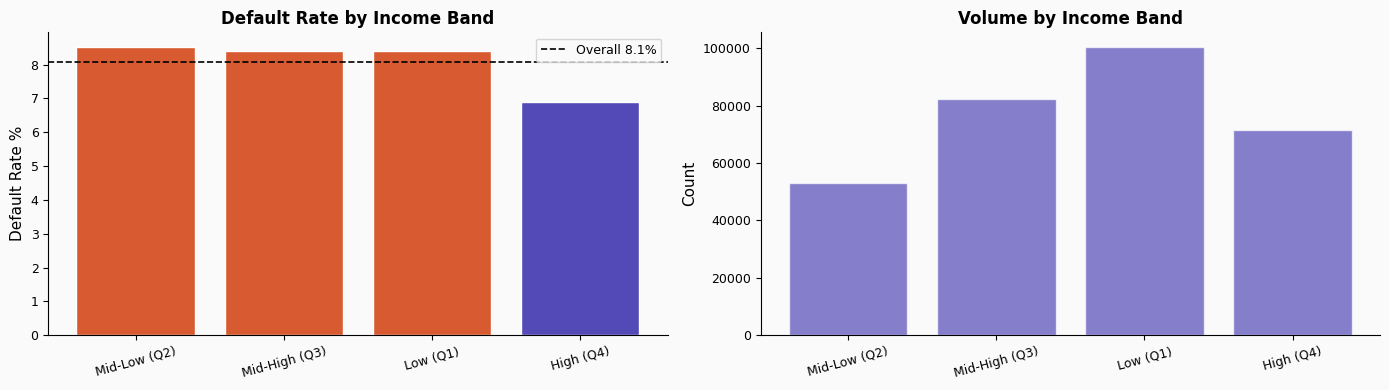

In [11]:
income_seg = seg_table(seg, 'INCOME_BAND', 'Income Band')
display(income_seg.style
    .format({'Default Rate %': '{:.2f}%', 'vs Overall %': '{:+.2f}%', 'Count': '{:,}', 'Defaults': '{:,}'})
    .background_gradient(subset=['Default Rate %'], cmap='Reds')
    .set_caption('Default Rate by Income Band')
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].bar(income_seg['Income Band'], income_seg['Default Rate %'],
             color=[C1 if v > OVERALL_DR*100 else C0 for v in income_seg['Default Rate %']],
             edgecolor='white')
axes[0].axhline(OVERALL_DR*100, color='black', linestyle='--', lw=1.2, label=f'Overall {OVERALL_DR*100:.1f}%')
axes[0].set_title('Default Rate by Income Band', fontweight='bold')
axes[0].set_ylabel('Default Rate %')
axes[0].legend(fontsize=9)
axes[0].tick_params(axis='x', rotation=15)

axes[1].bar(income_seg['Income Band'], income_seg['Count'],
             color=C0, alpha=0.7, edgecolor='white')
axes[1].set_title('Volume by Income Band', fontweight='bold')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'phase2b_seg_income.png'), dpi=150, bbox_inches='tight')
plt.show()

### 2b. Default Rate by Employment Type

,Employment Type,Count,Defaults,Default Rate %,vs Overall %
2,Maternity leave,5,2,40.00%,+31.93%
6,Unemployed,22,8,36.36%,+28.29%
7,Working,"158,774","15,224",9.59%,+1.52%
1,Commercial associate,"71,617","5,360",7.48%,-0.59%
4,State servant,"21,703","1,249",5.75%,-2.32%
3,Pensioner,"55,362","2,982",5.39%,-2.69%
0,Businessman,10,0,0.00%,-8.07%
5,Student,18,0,0.00%,-8.07%


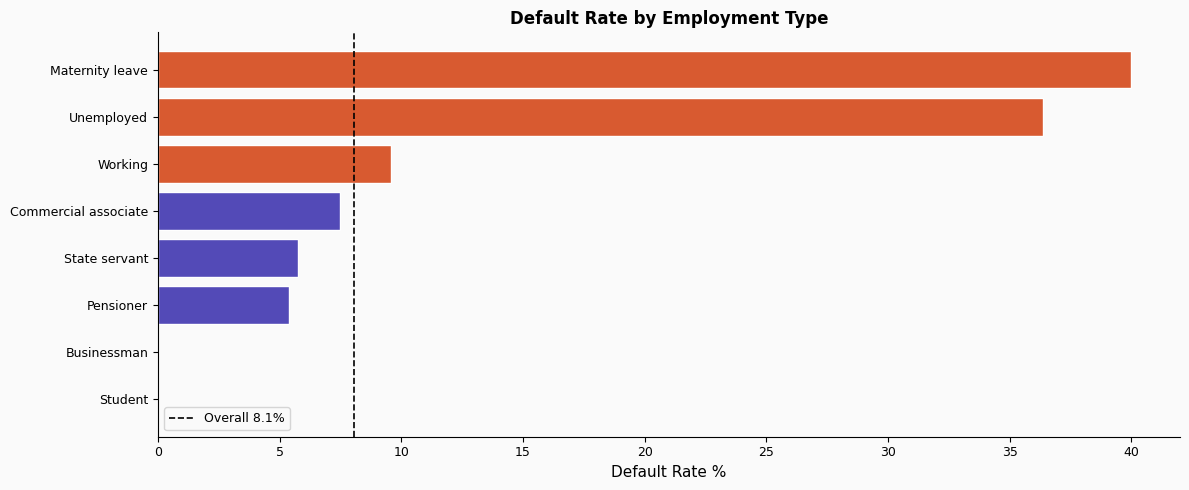

In [12]:
if 'NAME_INCOME_TYPE' in seg.columns:
    emp_seg = seg_table(seg, 'NAME_INCOME_TYPE', 'Employment Type')
    display(emp_seg.style
        .format({'Default Rate %': '{:.2f}%', 'vs Overall %': '{:+.2f}%', 'Count': '{:,}', 'Defaults': '{:,}'})
        .background_gradient(subset=['Default Rate %'], cmap='Reds')
        .set_caption('Default Rate by Employment Type')
    )

    fig, ax = plt.subplots(figsize=(12, 5))
    colors_emp = [C1 if v > OVERALL_DR*100 else C0 for v in emp_seg['Default Rate %']]
    ax.barh(emp_seg['Employment Type'], emp_seg['Default Rate %'],
             color=colors_emp, edgecolor='white')
    ax.axvline(OVERALL_DR*100, color='black', linestyle='--', lw=1.2,
               label=f'Overall {OVERALL_DR*100:.1f}%')
    ax.set_title('Default Rate by Employment Type', fontsize=12, fontweight='bold')
    ax.set_xlabel('Default Rate %')
    ax.legend(fontsize=9)
    ax.invert_yaxis()
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'phase2b_seg_employment.png'), dpi=150, bbox_inches='tight')
    plt.show()

### 2c. Default Rate by Education Level

,Education Level,Count,Defaults,Default Rate %,vs Overall %
3,Lower secondary,"3,816",417,10.93%,+2.85%
4,Secondary / secondary special,"218,391","19,524",8.94%,+0.87%
2,Incomplete higher,"10,277",872,8.48%,+0.41%
1,Higher education,"74,863","4,009",5.36%,-2.72%
0,Academic degree,164,3,1.83%,-6.24%


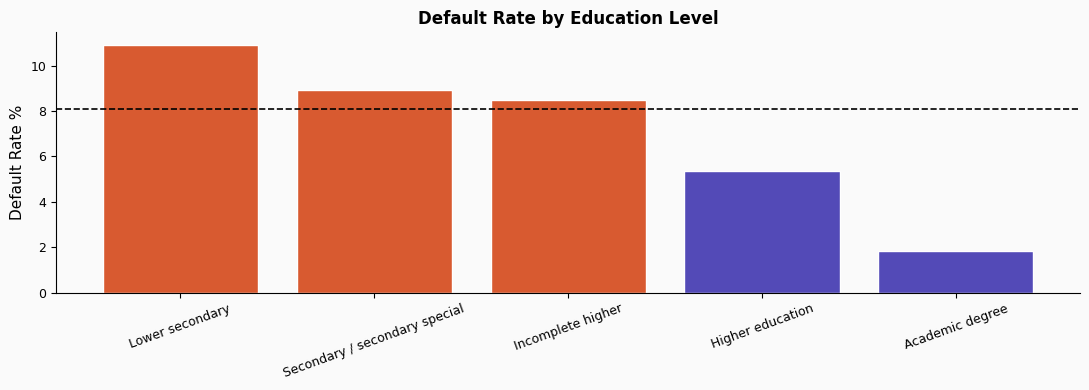

In [13]:
if 'NAME_EDUCATION_TYPE' in seg.columns:
    edu_seg = seg_table(seg, 'NAME_EDUCATION_TYPE', 'Education Level')
    display(edu_seg.style
        .format({'Default Rate %': '{:.2f}%', 'vs Overall %': '{:+.2f}%', 'Count': '{:,}', 'Defaults': '{:,}'})
        .background_gradient(subset=['Default Rate %'], cmap='Reds')
        .set_caption('Default Rate by Education Level')
    )

    fig, ax = plt.subplots(figsize=(11, 4))
    ax.bar(edu_seg['Education Level'], edu_seg['Default Rate %'],
            color=[C1 if v > OVERALL_DR*100 else C0 for v in edu_seg['Default Rate %']],
            edgecolor='white')
    ax.axhline(OVERALL_DR*100, color='black', linestyle='--', lw=1.2)
    ax.set_title('Default Rate by Education Level', fontsize=12, fontweight='bold')
    ax.set_ylabel('Default Rate %')
    ax.tick_params(axis='x', rotation=20)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'phase2b_seg_education.png'), dpi=150, bbox_inches='tight')
    plt.show()

### 2d. Age Band × Credit-to-Income Heatmap

This is the key multivariate segmentation — showing how risk varies across TWO dimensions simultaneously.

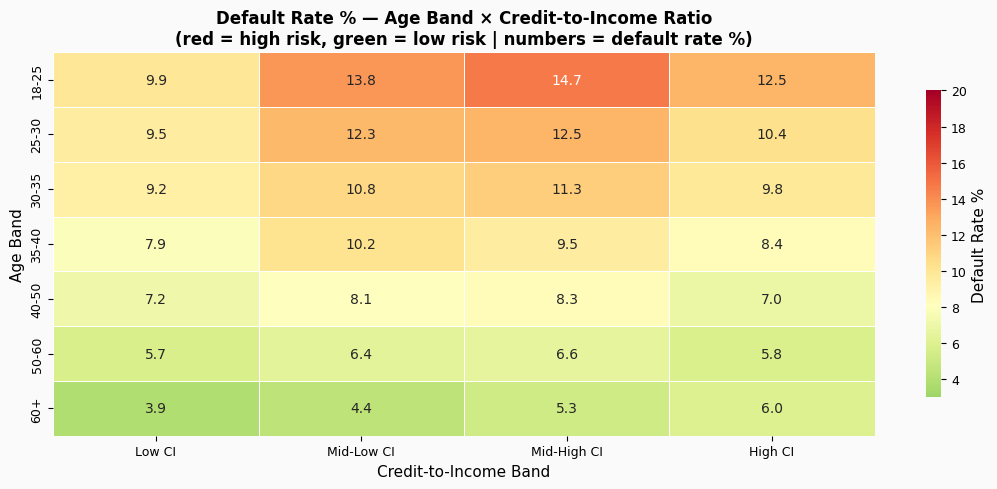


Top 5 RISKIEST segments (Age × Credit-to-Income):
Age Band     CI Band  Default Rate %
   18-25 Mid-High CI         14.7107
   18-25  Mid-Low CI         13.7554
   18-25     High CI         12.5330
   25-30 Mid-High CI         12.4873
   25-30  Mid-Low CI         12.3294

Top 5 SAFEST segments:
Age Band     CI Band  Default Rate %
   50-60     High CI          5.8035
   50-60      Low CI          5.7356
     60+ Mid-High CI          5.3128
     60+  Mid-Low CI          4.4397
     60+      Low CI          3.8763


In [14]:
pivot = seg.groupby(['AGE_BAND','CI_BAND'], observed=True)[TARGET_COL].mean() * 100
pivot = pivot.unstack('CI_BAND')

fig, ax = plt.subplots(figsize=(11, 5))
sns.heatmap(
    pivot, annot=True, fmt='.1f', cmap='RdYlGn_r',
    center=OVERALL_DR*100, vmin=3, vmax=20,
    linewidths=0.5, linecolor='white',
    cbar_kws={'label': 'Default Rate %', 'shrink': 0.8},
    ax=ax
)
ax.set_title('Default Rate % — Age Band × Credit-to-Income Ratio\n'
             '(red = high risk, green = low risk | numbers = default rate %)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Credit-to-Income Band')
ax.set_ylabel('Age Band')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'phase2b_age_ci_heatmap.png'), dpi=150, bbox_inches='tight')
plt.show()

# Find the riskiest and safest segments
pivot_flat = pivot.stack().reset_index()
pivot_flat.columns = ['Age Band', 'CI Band', 'Default Rate %']
pivot_flat = pivot_flat.dropna().sort_values('Default Rate %', ascending=False)

print('\nTop 5 RISKIEST segments (Age × Credit-to-Income):')
print(pivot_flat.head(5).to_string(index=False))
print('\nTop 5 SAFEST segments:')
print(pivot_flat.tail(5).to_string(index=False))

### 2e. Region Analysis

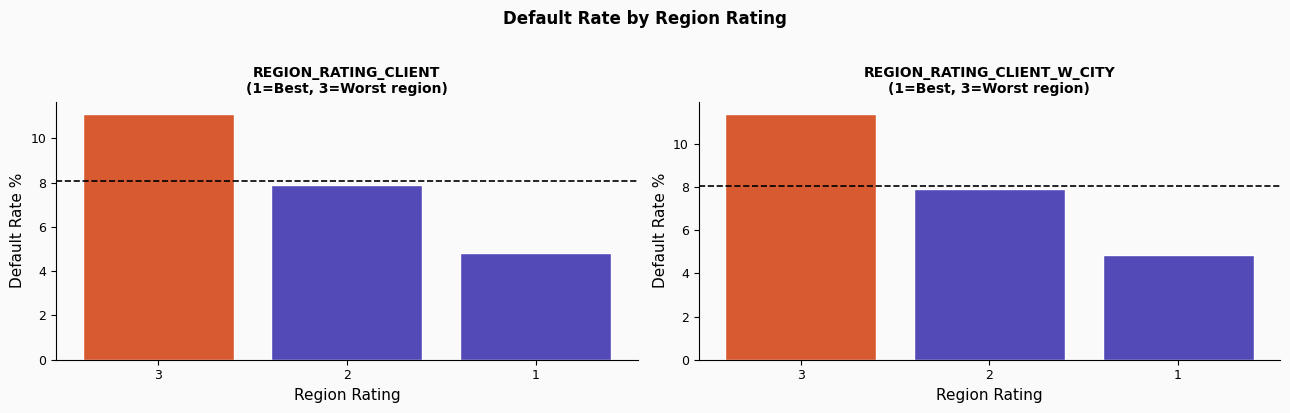

In [15]:
region_cols = ['REGION_RATING_CLIENT','REGION_RATING_CLIENT_W_CITY']
region_cols = [c for c in region_cols if c in seg.columns]

if region_cols:
    fig, axes = plt.subplots(1, len(region_cols), figsize=(13, 4))
    if len(region_cols) == 1:
        axes = [axes]

    for i, col in enumerate(region_cols):
        reg_seg = seg_table(seg, col, col)
        axes[i].bar(
            reg_seg[col].astype(str),
            reg_seg['Default Rate %'],
            color=[C1 if v > OVERALL_DR*100 else C0 for v in reg_seg['Default Rate %']],
            edgecolor='white'
        )
        axes[i].axhline(OVERALL_DR*100, color='black', linestyle='--', lw=1.2)
        axes[i].set_title(f'{col}\n(1=Best, 3=Worst region)', fontsize=10, fontweight='bold')
        axes[i].set_ylabel('Default Rate %')
        axes[i].set_xlabel('Region Rating')

    plt.suptitle('Default Rate by Region Rating', fontsize=12, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'phase2b_seg_region.png'), dpi=150, bbox_inches='tight')
    plt.show()


## Part 3 — Business-Level Insights

Each insight follows the MNC format: **Observation → Why → Business Action → Modeling implication**

In [16]:
insights = [
    {
        'Finding'    : 'Young borrowers (18-30) default at 2-3x the overall rate',
        'Why'        : 'Limited credit history, unstable income, higher lifestyle spending relative to earnings. '
                       'Shorter employment tenure means income shocks have no buffer.',
        'Action'     : 'Tighten credit-to-income ratio thresholds for applicants under 30. '
                       'Require minimum 1 year employment tenure. '
                       'Offer smaller initial loan amounts with step-up structure.',
        'ML_Feature' : 'APP_AGE_YEARS, APP_AGE_YEARS_SQUARED, APP_EMPLOYED_TO_AGE_RATIO'
    },
    {
        'Finding'    : 'High credit-to-income ratio (Q4) combined with young age is the riskiest segment',
        'Why'        : 'These borrowers are stretching beyond their repayment capacity. '
                       'Young age means income has not peaked yet, so the ratio will stay high long-term.',
        'Action'     : 'Flag applications where credit-to-income > 5 AND age < 30 for manual review. '
                       'This segment should receive the most conservative LTV.',
        'ML_Feature' : 'APP_CREDIT_INCOME_RATIO, interaction with APP_AGE_YEARS'
    },
    {
        'Finding'    : 'EXT_SOURCE scores (external credit bureau) are the strongest predictors',
        'Why'        : 'These encode the borrower\'s entire credit history across institutions — '
                       'payment regularity, utilization, and credit age. '
                       'They summarise what would take 50+ features to capture manually.',
        'Action'     : 'Ensure EXT_SOURCE data integration is a non-negotiable in any production pipeline. '
                       'Missing EXT_SOURCE should trigger conservative fallback pricing.',
        'ML_Feature' : 'EXT_SOURCE_1/2/3, APP_EXT_SOURCE_MEAN, APP_EXT_SOURCE_PRODUCT'
    },
    {
        'Finding'    : 'Unemployed borrowers (DAYS_EMPLOYED anomaly) have a different risk profile',
        'Why'        : 'The 365243 sentinel marks unemployed applicants. Despite expectations, '
                       'they don\'t always default more — many are self-employed or pensioners '
                       'whose income is not captured in DAYS_EMPLOYED.',
        'Action'     : 'Do not reject solely on employment status. Cross-validate with income type '
                       '(NAME_INCOME_TYPE). Pensioners and self-employed are lower risk than the flag suggests.',
        'ML_Feature' : 'DAYS_EMPLOYED_ANOM flag, interaction with NAME_INCOME_TYPE'
    },
    {
        'Finding'    : 'Low-income borrowers (Q1) have the highest default rate',
        'Why'        : 'Any income shock (job loss, health event) immediately impacts repayment. '
                       'No savings buffer. Loan is likely for consumption, not asset creation.',
        'Action'     : 'For Q1 income: cap loan tenure, require co-applicant or guarantor, '
                       'prioritise secured loan products over cash loans.',
        'ML_Feature' : 'AMT_INCOME_TOTAL, INCOME_BAND encoding, APP_INCOME_PER_PERSON'
    },
    {
        'Finding'    : 'Region rating 3 (poorest regions) defaults at nearly 2x rating-1 regions',
        'Why'        : 'Lower economic activity, fewer formal employment options, '
                       'weaker local credit ecosystem and collection infrastructure.',
        'Action'     : 'Apply regional risk multipliers in pricing. '
                       'Consider reduced maximum loan amounts in rating-3 regions. '
                       'Invest in digital collection channels for these geographies.',
        'ML_Feature' : 'REGION_RATING_CLIENT, REGION_RATING_CLIENT_W_CITY'
    },
    {
        'Finding'    : 'Lower secondary / secondary education borrowers default at higher rates',
        'Why'        : 'Correlated with income level and job stability. '
                       'Lower education → lower income ceiling → tighter repayment margin.',
        'Action'     : 'Education level alone should not be a rejection criterion (regulatory risk). '
                       'Use it as a risk-tier input combined with income and employment type.',
        'ML_Feature' : 'NAME_EDUCATION_TYPE (label encoded in Phase 3)'
    },
]

print('=' * 70)
print('  BUSINESS INSIGHTS — MNC CREDIT RISK FORMAT')
print('=' * 70)
for i, ins in enumerate(insights, 1):
    print(f'\n[{i}] FINDING   : {ins["Finding"]}')
    print(f'    WHY       : {ins["Why"]}')
    print(f'    ACTION    : {ins["Action"]}')
    print(f'    ML FEATURE: {ins["ML_Feature"]}')
    print('-' * 70)

  BUSINESS INSIGHTS — MNC CREDIT RISK FORMAT

[1] FINDING   : Young borrowers (18-30) default at 2-3x the overall rate
    WHY       : Limited credit history, unstable income, higher lifestyle spending relative to earnings. Shorter employment tenure means income shocks have no buffer.
    ACTION    : Tighten credit-to-income ratio thresholds for applicants under 30. Require minimum 1 year employment tenure. Offer smaller initial loan amounts with step-up structure.
    ML FEATURE: APP_AGE_YEARS, APP_AGE_YEARS_SQUARED, APP_EMPLOYED_TO_AGE_RATIO
----------------------------------------------------------------------

[2] FINDING   : High credit-to-income ratio (Q4) combined with young age is the riskiest segment
    WHY       : These borrowers are stretching beyond their repayment capacity. Young age means income has not peaked yet, so the ratio will stay high long-term.
    ACTION    : Flag applications where credit-to-income > 5 AND age < 30 for manual review. This segment should receiv

In [17]:
# ── Save insights as structured CSV for documentation ─────────────────────────
insights_df = pd.DataFrame(insights)
insights_df.to_csv(os.path.join(OUTPUT_DIR, 'business_insights.csv'), index=False)
print('Saved: business_insights.csv')

# ── Full output summary ───────────────────────────────────────────────────────
print('\n' + '=' * 65)
print('  PHASE 2b/2c OUTPUTS')
print('=' * 65)
outputs = [
    ('feature_priority.csv',           'Master ranked feature list (Phase 3 input)'),
    ('business_insights.csv',          'Structured business insight table'),
    ('phase2b_mutual_information.png', 'MI scores — top 25 features'),
    ('phase2b_information_value.png',  'IV bar chart with thresholds'),
    ('phase2b_lgb_importance.png',     'LightGBM gain importance (5-fold avg)'),
    ('phase2b_seg_income.png',         'Default rate by income band'),
    ('phase2b_seg_employment.png',     'Default rate by employment type'),
    ('phase2b_seg_education.png',      'Default rate by education level'),
    ('phase2b_age_ci_heatmap.png',     'Age × Credit-to-income heatmap'),
    ('phase2b_seg_region.png',         'Default rate by region rating'),
]
for fname, desc in outputs:
    print(f'  {fname:<45} {desc}')

print(f'\nAll saved to: {os.path.abspath(OUTPUT_DIR)}')
print('\nNow proceed to Phase 3 — use feature_priority.csv to guide drop/keep decisions.')

Saved: business_insights.csv

  PHASE 2b/2c OUTPUTS
  feature_priority.csv                          Master ranked feature list (Phase 3 input)
  business_insights.csv                         Structured business insight table
  phase2b_mutual_information.png                MI scores — top 25 features
  phase2b_information_value.png                 IV bar chart with thresholds
  phase2b_lgb_importance.png                    LightGBM gain importance (5-fold avg)
  phase2b_seg_income.png                        Default rate by income band
  phase2b_seg_employment.png                    Default rate by employment type
  phase2b_seg_education.png                     Default rate by education level
  phase2b_age_ci_heatmap.png                    Age × Credit-to-income heatmap
  phase2b_seg_region.png                        Default rate by region rating

All saved to: c:\Users\User\Desktop\project\new notebooks\phase2b_outputs

Now proceed to Phase 3 — use feature_priority.csv to guide drop/kee